In [1]:
import pandas, numpy as np
import matplotlib.pyplot as plt
from collections import namedtuple
import json
import scipy.optimize

In [2]:
q0 = 79.53 # [A^2]
r0 = 66.69 # [A^3]
z_coordination = 10
c_hb = 85580.0 # kcal A^4 / mol/e^2
R = 8.3144598/4184 # 0.001987 # but really: 8.3144598/4184
sigma_hb = 0.0084
EPS = 3.667 # (LIN AND SANDLER USE A CONSTANT FPOL WHICH YIELDS EPS=3.68)
AEFFPRIME = 7.5
EO = 2.395e-4
FPOL = (EPS-1.0)/(EPS+0.5)
ALPHA = (0.3*AEFFPRIME**(1.5))/(EO)
alpha_prime = FPOL*ALPHA
print(alpha_prime, R)

16466.721761795383 0.001987203585086042


In [3]:
sigma_tabulated = np.linspace(-0.025, 0.025, 51)
sigma_m = np.tile(sigma_tabulated,(len(sigma_tabulated),1))
sigma_n = np.tile(np.array(sigma_tabulated,ndmin=2).T,(1,len(sigma_tabulated)))
sigma_acc = np.tril(sigma_n) + np.triu(sigma_m,1)
sigma_don = np.tril(sigma_m) + np.triu(sigma_n,1)
DELTAW = (alpha_prime/2)*(sigma_m + sigma_n)**2+ c_hb*np.maximum(0, sigma_acc - sigma_hb)*np.minimum(0, sigma_don+sigma_hb)

In [4]:
class _fac(object):
    def __init__(self, j):
        assert(j['using_tau_r'])
        self.T_r = j['T_r']
        self.T_max = j['Tmax']
        self.T_min = j['Tmin']
        self.n = np.array(j['n'])
        self.t = np.array(j['t'])
        self.reducing_value = j['reducing_value']
    
    def psat(self, T):
        theta = 1-T/self.T_r
        RHS = np.dot(self.n,theta**self.t)
        return self.reducing_value*np.exp(self.T_r/T*np.sum(RHS))
    
    def dpsat_dT(self, T):
        im = 0+1j; h = 1e-10
        return (self.psat(T+im*h)/h).imag
        
def psat_factory(fluid):
    # Get the JSON structure from CoolProp
    pS = json.loads(CP.get_fluid_param_string(fluid,'JSON'))[0]['ANCILLARIES']['pS']
    return _fac(pS)
    
Ttest = 300
import CoolProp.CoolProp as CP
for fluid in ['Acetone','Water','Ethanol','Benzene']:
    fac = psat_factory(fluid)
    assert(abs(fac.psat(Ttest)-CP.PropsSI('P','T',Ttest,'Q',0,fluid))/fac.psat(Ttest) < 1e-3)
    AS = CP.AbstractState('HEOS',fluid)
    AS.update(CP.QT_INPUTS, 0, Ttest)
    assert(abs(AS.first_saturation_deriv(CP.iP, CP.iT) - fac.dpsat_dT(Ttest))/fac.dpsat_dT(Ttest) < 1e-3)

In [5]:
def get_sigma_profile(name):
    DIR = '/Users/charlles/MIT/COSMOSAC'
    df = pandas.read_csv(DIR + '/profiles/VT2005/Sigma_Profile_Database_Index_v2.txt', sep = '\t')
    mask = df['Compound Name'] == name
    assert(sum(mask)==1)
    index = int(df[mask]['Index No.'].iloc[0])
    V_COSMO = float(df[mask]['Vcosmo, A3'].iloc[0])
    with open(DIR + '/profiles/VT2005/Sigma_Profiles_v2/VT2005-'+'{0:04d}'.format(index)+'-PROF.txt') as fp:
        dd = pandas.read_csv(fp,names=['sigma [e/A^2]','p(sigma)*A [A^2]'],sep='\s+')
        dd['A'] = dd['p(sigma)*A [A^2]'].sum()
        dd['p(sigma)'] = dd['p(sigma)*A [A^2]']/dd['A']
        return dd, V_COSMO

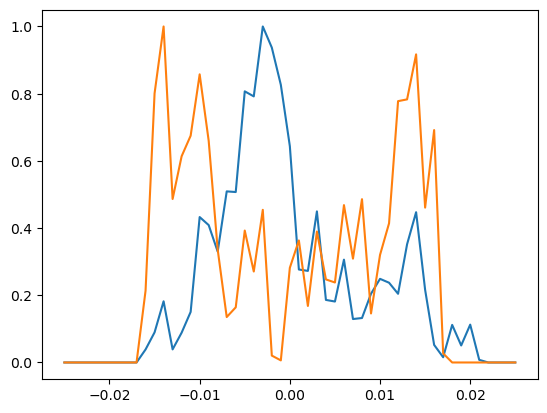

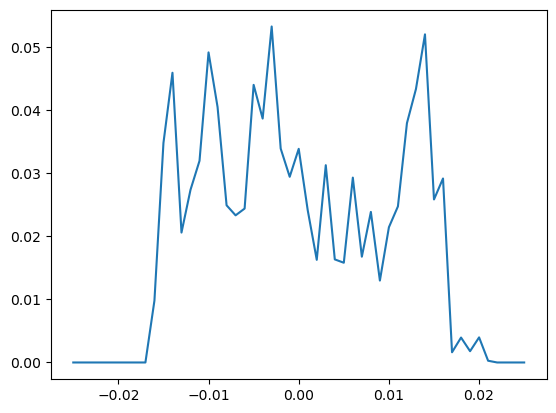

In [10]:
def sigma_plots():
    profs = [get_sigma_profile(n)[0] for n in ['MONOETHANOLAMINE','WATER']]
    As = [prof['p(sigma)*A [A^2]'].sum() for prof in profs]
    for prof in profs:
        plt.plot(prof['sigma [e/A^2]'], prof['p(sigma)*A [A^2]']/prof['p(sigma)*A [A^2]'].max())
    plt.figure()
    x = [0.235000029,1-0.235000029]
    psigma_mix = sum([x[i]*profs[i]['p(sigma)*A [A^2]'] for i in range(2)])/sum([x[i]*As[i] for i in range(2)])
    plt.plot(profs[0]['sigma [e/A^2]'], psigma_mix);
sigma_plots()

In [11]:
def get_Gamma(T, psigma):
    """
    Get the value of Γ (capital gamma) for the given sigma profile
    """
    Gamma = np.ones_like(psigma)
    AA = np.exp(-DELTAW/(R*T))*psigma # constant and can be pre-calculated outside of the loop
    for i in range(50):
        Gammanew = 1/np.sum(AA*Gamma, axis=1)
        difference = np.abs((Gamma-Gammanew)/Gamma)
        Gamma = (Gammanew + Gamma)/2
        if np.max(difference) < 1e-8:
            break
        else:
            pass
    print(i)
    return Gamma

def get_lngamma_resid(T, i, psigma_mix, prof, lnGamma_mix = None):
    """
    The residual contribution to ln(γ_i)
    """
    # For the mixture
    if lnGamma_mix is None:
        lnGamma_mix = np.log(get_Gamma(T, np.array(psigma_mix)))
    # For this component
    psigma = np.array(prof['p(sigma)'])
    A_i = prof['A'].iloc[0]
    lnGammai = np.log(get_Gamma(T, psigma))
    lngammai = A_i/AEFFPRIME*np.sum(psigma*(lnGamma_mix - lnGammai))
    return lngammai

def get_lngamma_comb(T, x, i, profs, V_COSMO_A3):
    """ 
    The combinatorial part of ln(γ_i)
    """
    A = np.array([prof['p(sigma)*A [A^2]'].sum() for prof in profs])
    q = A/q0
    r = V_COSMO_A3/r0
    theta_i = x[i]*q[i]/np.dot(x,q)
    phi_i = x[i]*r[i]/np.dot(x,r)
    l = z_coordination/2*(r-q) - (r-1)
    return (np.log(phi_i/x[i])+z_coordination/2*q[i]*np.log(theta_i/phi_i)
           +l[i]-phi_i/x[i]*np.dot(x,l))

def get_lngamma(T, x, i, psigma_mix, profs, V_COSMO_A3, lnGamma_mix = None):
    """ 
    Sum of the contributions to ln(γ_i)
    """
    return (get_lngamma_resid(T, i, psigma_mix, profs[i], lnGamma_mix=lnGamma_mix) 
           + get_lngamma_comb(T, x, i, profs, V_COSMO_A3))

In [15]:
profs = [get_sigma_profile(n)[0] for n in ['MONOETHANOLAMINE','WATER']]
As = [prof['p(sigma)*A [A^2]'].sum() for prof in profs]
x = [0.235,1-0.235]
T = 348.15
psigma_mix = sum([x[i]*profs[i]['p(sigma)*A [A^2]'] for i in range(2)])/sum([x[i]*As[i] for i in range(2)])
profs,V_COSMO_A3 = zip(*[get_sigma_profile(name) for name in ['MONOETHANOLAMINE','WATER']])
# print(profs)
V_COSMO_A3 = np.array(V_COSMO_A3)
lnGamma_mix = np.log(get_Gamma(T, np.array(psigma_mix)))
for i in range(2):
    print(i, get_lngamma_resid(T, i, psigma_mix, profs[i], lnGamma_mix=lnGamma_mix) )
    print(i, get_lngamma_comb(T, x, i, profs, V_COSMO_A3))
    get_lngamma(T, x, i, np.array(psigma_mix), profs, V_COSMO_A3, lnGamma_mix = lnGamma_mix)

49
49
0 -0.10628534568312982
0 -0.27687819657408086
49
49
1 0.05560651860202024
1 -0.05226631805276108
49


In [ ]:
from cosmolayer import Component
from importlib.resources import files
path = files("cosmolayer.data") / "C=C(N)O.cosmo"
component = Component(path)
psigma = component.get_segment_type_distribution(merged=True)
psigma.sum(), psigma.shape

In [ ]:
psigma

In [ ]:
# B = np.array(
#     [[1.  , 2.24, 0.45, 0.82, 0.30],
#      [2.24, 1.  , 0.67, 3.35, 0.92],
#      [0.45, 0.67, 1.  , 0.45, 0.30],
#      [0.82, 3.35, 0.45, 1.  , 0.67],
#      [0.30, 0.92, 0.30, 0.67, 1.  ]],
# )
# T = 298.15
# DELTAW = -R*T*np.log(B)
# psigma = 0.2 * np.ones(5)

In [ ]:
T = 298.15
# psigma = np.array(profs[0]["p(sigma)"])
B = np.exp(-DELTAW / (R * T))
# Gamma = np.ones_like(psigma)
Gamma = 1 / (B @ psigma)
AA = B * psigma  # constant and can be pre-calculated outside of the loop
for i in range(50):
    Gammanew = 1 / np.sum(AA * Gamma, axis=1)
    difference = np.abs((Gamma - Gammanew) / Gamma)
    Gamma += 0.75 * (Gammanew - Gamma)
    if np.max(difference) < 1e-8:
        break
print(i)


In [ ]:
T = 298.15
# psigma = np.array(profs[0]["p(sigma)"])
B = np.exp(-DELTAW / (R * T))
# Gamma = np.ones_like(psigma)
Gamma = 1 / (B @ psigma)
AA = B * psigma  # constant and can be pre-calculated outside of the loop
for i in range(1000):
    Gammanew = 1 / np.sum(AA * Gamma, axis=1)
    difference = np.abs((Gamma - Gammanew) / Gamma)
    Gamma += 0.75 * (Gammanew - Gamma)
    if np.max(difference) < 1e-8:
        break
print(i)

In [ ]:
z = psigma
gamma = 1 / (B @ z)
f = B @ (psigma / gamma - z)
J = -(B * np.diag(z * gamma) * B + B)
from numpy.linalg import solve, cholesky
L = cholesky(J)


In [ ]:
import pandas as pd
pd.DataFrame({"inv_gamma": -np.log(1/Gamma), "Gamma": np.log(Gamma)})

In [ ]:
np.log(Gamma)

In [ ]:
np.log(Gamma)

In [ ]:
function [x ,k] = sinkhorn (A, maxiter , tol , s)
n = size (A,1) ; % dimension , matrix order
x = ones(n,1) ; % initialize x−values with all−ones vector
if s== 1 % Sinnkhorn ’ s algorithm S1
K = A(1 ,:) > 0;
if all (K)
alpha = sqrt (min(A(:) ) ) ; % minimum nonzero entry of A
else % infinite dilution
AK = A(K,K) ; alpha = sqrt (min(AK(:) ) ) ;
end
x = alpha∗x; % initialize x−values
end
y = (A∗x).^−1; % initialize y−values
% initialize iteration counter
k = 0; t = tol + 1;
while t > tol & k < maxiter
x_ = (A∗x).^−1; % new x−values
if s== 1 % Sinnkhorn ’ s algorithm S1
x_ = x_/( alpha∗norm(x_ , ’ inf ’ ) ) ; % new x−values
end
y_ = (A∗x_).^−1; % new y−values
tx = norm((x−x_) ./ x , ’ inf ’ ) ; % relative x−deviation
ty = norm((y−y_) ./ y , ’ inf ’ ) ; % relative y−deviation
t = max(tx , ty ) ; % overall maximum norm
x = x_ ; % update old x−values for next loop
y = y_ ; % update old y−values for next loop
k = k+1; % increment iteration counter
end
x = sqrt (y(1) /x(1) )∗x ; % final result

In [ ]:
import torch


def sinkhorn_torch(A, maxiter=100, tol=1e-8, s=1):
    """
    Sinkhorn's algorithm for matrix scaling.

    Parameters
    ----------
    A : torch.Tensor
        Input matrix, shape [n, n]
    maxiter : int
        Maximum number of iterations
    tol : float
        Tolerance for convergence
    s : int
        Algorithm variant (1 for Sinkhorn's algorithm S1, 0 otherwise)

    Returns
    -------
    x : torch.Tensor
        Scaling vector, shape [n]
    k : int
        Number of iterations performed
    """
    n = A.shape[0]  # dimension, matrix order
    x = torch.ones(n, dtype=A.dtype, device=A.device)  # initialize x-values

    if s == 1:  # Sinkhorn's algorithm S1
        K = A[0, :] > 0
        if K.all():
            alpha = torch.sqrt(A.min())  # minimum nonzero entry of A
        else:  # infinite dilution
            AK = A[K][:, K]
            alpha = torch.sqrt(AK.min())
        x = alpha * x  # initialize x-values

    y = (A @ x).reciprocal()  # initialize y-values

    # initialize iteration counter
    k = 0
    t = tol + 1

    while t > tol and k < maxiter:
        x_ = (A @ x).reciprocal()  # new x-values

        if s == 1:  # Sinkhorn's algorithm S1
            x_ = x_ / (alpha * torch.norm(x_, p=float("inf")))  # new x-values

        y_ = (A @ x_).reciprocal()  # new y-values

        tx = torch.norm((x - x_) / x, p=float("inf"))  # relative x-deviation
        ty = torch.norm((y - y_) / y, p=float("inf"))  # relative y-deviation
        t = max(tx.item(), ty.item())  # overall maximum norm

        x = x_  # update old x-values for next loop
        y = y_  # update old y-values for next loop
        k = k + 1  # increment iteration counter

    x = torch.sqrt(y[0] / x[0]) * x  # final result

    return x, k


import numpy as np


def sinkhorn_numpy(B, p, maxiter=1000, tol=1e-8, s=1):
    A = B * p
    n = A.shape[0]  # dimension, matrix order
    x = np.ones(n, dtype=A.dtype)  # initialize x-values

    if s == 1:  # Sinkhorn's algorithm S1
        K = A[0, :] > 0
        if K.all():
            alpha = np.sqrt(A.min())  # minimum nonzero entry of A
        else:  # infinite dilution
            AK = A[np.ix_(K, K)]
            alpha = np.sqrt(AK.min())
        x = alpha * x  # initialize x-values


    y = 1 / (A @ x)  # initialize y-values

    # initialize iteration counter
    k = 0
    t = tol + 1

    while t > tol and k < maxiter:
        x_ = 1 / (A @ x)  # new x-values

        if s == 1:  # Sinkhorn's algorithm S1
            x_ = x_ / (alpha * np.linalg.norm(x_, ord=np.inf))  # new x-values

        y_ = 1 / (A @ x_)  # new y-values

        tx = np.linalg.norm((x - x_) / x, ord=np.inf)  # relative x-deviation
        ty = np.linalg.norm((y - y_) / y, ord=np.inf)  # relative y-deviation
        t = max(tx, ty)  # overall maximum norm

        x = x_  # update old x-values for next loop
        y = y_  # update old y-values for next loop
        k = k + 1  # increment iteration counter

    x = np.sqrt(y[0] / x[0]) * x  # final result

    return x, k

In [ ]:
x, n = sinkhorn_numpy(B, psigma, tol=1e-10,s=1)
n

In [ ]:
n

In [ ]:
x

In [ ]:
Gamma